In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")
def data_summary (df, name):
  print(f"\n{name} Dataset")
  print("Shape:", df.shape)
  print("missising values:\n", df.isnull().sum())
  print("Duplicates:", df.duplicated().sum())
data_summary(trades, "Trades")
data_summary(sentiment, "Sentiment")


Trades Dataset
Shape: (211224, 16)
missising values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicates: 0

Sentiment Dataset
Shape: (2644, 4)
missising values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates: 0


In [4]:
#convert trade timestamp
trades["Timestamp"] = pd.to_datetime(
    trades["Timestamp"],
    unit="ms",
    errors="coerce")
trades["date"] = trades["Timestamp"].dt.date

#covert sentiment
sentiment["timestamp"] = pd.to_datetime(
    sentiment["timestamp"],
    unit="s",
    errors= "coerce")
sentiment["date"]= sentiment["timestamp"].dt.date
merged_df=trades.merge(
    sentiment[["date", "value", "classification"]],
    on="date",
    how="left")
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,74.0,Greed


In [5]:
daily_pnl=(merged_df.groupby(["Account",
                          "date",])["Closed PnL"]
           .sum()
           .reset_index())
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04


In [6]:
#winRate
merged_df["win"] = merged_df["Closed PnL"] > 0
win_rate = (
    merged_df.groupby("Account")["win"]
                 .mean()
                 .reset_index(name= "win_rate"))
win_rate.head()

,Account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [7]:
#Avarage trade size
avg_trade_size = (
    merged_df.groupby("Account")["Size USD"]
    .mean()
    .reset_index(name="avg_trade_size"))
avg_trade_size.head()

,Account,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [8]:
#trades per day
trades_per_day = (
    merged_df.groupby(["date"])
    .size()
    .reset_index(name= "trades_per_day"))
trades_per_day.head()


,date,trades_per_day
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


In [9]:
#Long/short ratio

long_short = (
    merged_df.groupby(["date", "Direction"])
    .size()
    .unstack(fill_value=0))
long_short["long_short_ratio"]= (
    long_short.get("Buy" , 0)/
    long_short.get("sell", 1))
long_short.head()
    


Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion,long_short_ratio
date,,,,,,,,,,,,,
2023-03-28,0,0,0,0,0,0,3,0,0,0,0,0,0.0
2023-11-14,0,0,380,103,0,0,388,174,0,0,0,0,0.0
2024-03-09,0,88,2389,1931,0,13,1339,1114,75,0,13,0,88.0
2024-07-03,8,786,886,1799,0,0,918,2389,295,0,2,58,786.0
2024-10-27,0,5806,4725,4026,0,5,5088,5712,9833,0,7,39,5806.0


In [10]:
#Performance vs sentiment
sentiment_perf =(
    merged_df.groupby("classification")
    .agg(
        avg_pnl = ("Closed PnL" , "mean"),
        win_rate = ("win", "mean"),
        trades = ("Closed PnL", "count"))
)
sentiment_perf.head()
      

,avg_pnl,win_rate,trades
classification,,,
Extreme Greed,25.418772,0.490089,6962
Fear,50.047622,0.415146,133871
Greed,87.894859,0.446471,36289
Neutral,22.229713,0.317182,7141


In [11]:
#Behaviour change by sentiment
behaviour = (
    merged_df.groupby("classification")
    .agg(
        avg_trade_size= ("Size USD", "mean"),
        trades_per_days = ("date", "nunique"))
                          )
behaviour.head()

,avg_trade_size,trades_per_days
classification,,
Extreme Greed,5660.265764,1
Fear,5259.977837,1
Greed,3182.883845,3
Neutral,3058.848110,1


In [12]:
#trader segmentation
merged_df["leverage_bucket"] = pd.qcut(
    merged_df["Size USD"], q = 2, labels =["Low", "High"]
)
segments = (
    merged_df.groupby("leverage_bucket")
    .agg(
        avg_pnl= ("Closed PnL", "mean"),
        win_rate = ("win", "mean"))
    )
segments.head()

C:\Users\sarka\AppData\Local\Temp\ipykernel_21584\2379967894.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby("leverage_bucket")


,avg_pnl,win_rate
leverage_bucket,,
Low,4.381445,0.40717
High,93.116556,0.41536


consistency segmentation:


consistency
Inconsistent / Losing    17
consistent Winner        15
Name: count, dtype: int64

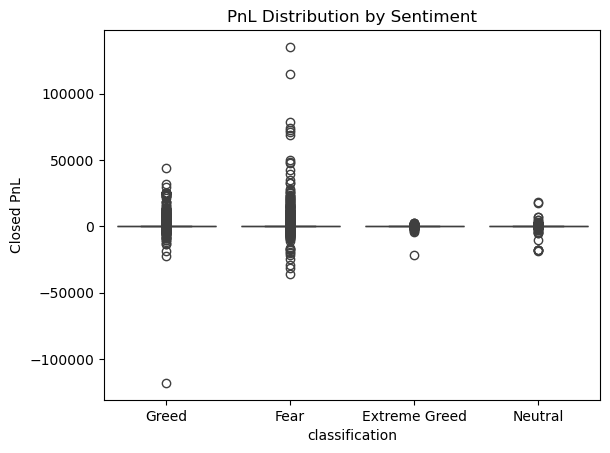

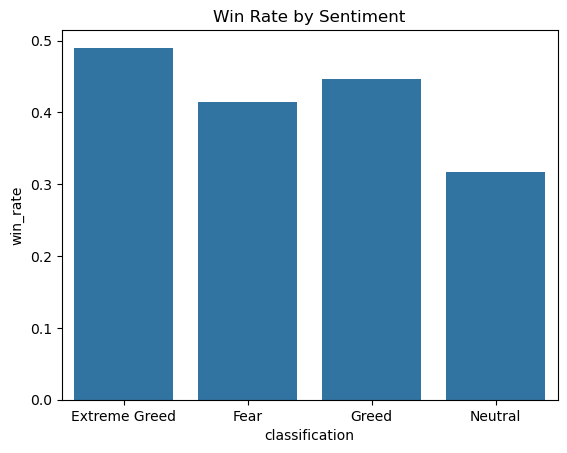

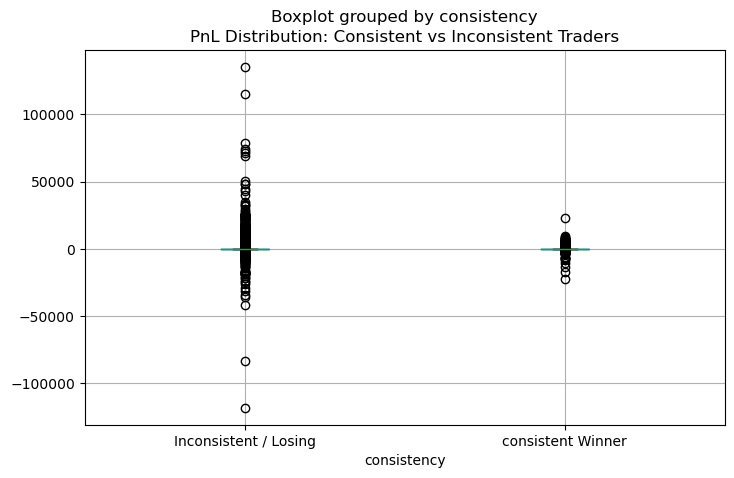

In [13]:
# trader-level performance
trader_perf = (
    merged_df.groupby("Account")
        .agg(
            avg_pnl=("Closed PnL", "mean"),
            pnl_std=("Closed PnL", "std"),
            win_rate=("Closed PnL", lambda x: (x > 0).mean()),
            total_trades=("Closed PnL", "count")
        )
        .reset_index())
vol_threshold = trader_perf["pnl_std"].median()
trader_perf["consistency"] = np.where(
    (trader_perf["avg_pnl"] > 0) & (trader_perf["pnl_std"] <= vol_threshold),
    "consistent Winner",
    "Inconsistent / Losing")

print("consistency segmentation:")
display(trader_perf["consistency"].value_counts())  

# Check if 'consistency' column already exists in merged_df and drop it if it does
if 'consistency' in merged_df.columns:
    merged_df = merged_df.drop('consistency', axis=1)
merged_df = merged_df.merge(
    trader_perf[["Account", "consistency"]],  
    on="Account",
    how="left")
import seaborn as sns
sns.boxplot(x="classification", y="Closed PnL", data=merged_df)  # Fixed parameter names
plt.title("PnL Distribution by Sentiment")
plt.show()

sns.barplot(x=sentiment_perf.index, y=sentiment_perf["win_rate"])  # Fixed parameter names
plt.title("Win Rate by Sentiment")
plt.show()

merged_df.boxplot(
    column="Closed PnL",
    by="consistency",
    figsize=(8,5))
plt.title("PnL Distribution: Consistent vs Inconsistent Traders")
plt.show()

In [15]:
daily_features = merged_df.groupby(['Account', 'date']).agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',
    'Trade ID' : 'count',
    'Direction': lambda x: (x== 'Buy').mean(),
    'value':'mean'}).reset_index()
daily_features.head()

,Account,date,Closed PnL,Size USD,Trade ID,Direction,value
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,14810.891818,462,0.000000,74.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,16345.241940,3356,0.000000,44.0
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,2492.749906,320,0.412500,74.0
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,1693.351684,3533,0.340787,44.0
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04,1533.468395,3427,0.176247,NaN


In [16]:
#Create profitability bucket
profit_bucket = pd.qcut(
    daily_features['Closed PnL'],
    q=3,
    labels=['loss', 'neutral', 'profit'])
profit_bucket.head()


0       loss
1     profit
2    neutral
3    neutral
4    neutral
Name: Closed PnL, dtype: category
Categories (3, object): ['loss' < 'neutral' < 'profit']

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

features = daily_features[['Size USD', 'Trade ID', 'Direction', 'value']]
target = profit_bucket

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=42, stratify=target
)
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5483870967741935
              precision    recall  f1-score   support

        loss       0.58      0.70      0.64        10
     neutral       0.33      0.30      0.32        10
      profit       0.70      0.64      0.67        11

    accuracy                           0.55        31
   macro avg       0.54      0.55      0.54        31
weighted avg       0.54      0.55      0.54        31



In [23]:
#trader clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
# First, check if 'Direction' is categorical and convert it to numeric
if daily_features['Direction'].dtype == 'object':
    # Convert categorical to numeric (example: map 'Buy' to 1, 'Sell' to 0)
    daily_features['Direction_numeric'] = daily_features['Direction'].map({'Buy': 1, 'Sell': 0})
    cluster_features = daily_features[['Size USD', 'Trade ID', 'Direction_numeric']]
else:
    cluster_features = daily_features[['Size USD', 'Trade ID', 'Direction']]

# Scale the features
scaled = StandardScaler().fit_transform(cluster_features)
# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
daily_features['cluster'] = kmeans.fit_predict(scaled)

numeric_cols = daily_features.select_dtypes(include=['number']).columns
daily_features.groupby('cluster')[numeric_cols].mean()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Closed PnL,Size USD,Trade ID,Direction,value,cluster
cluster,,,,,,
0,95953.780796,6770.367235,1432.461538,0.022647,59.545455,0.0
1,19692.679986,2889.525921,696.941176,0.582699,61.866667,1.0
2,353969.783088,1636.027263,12520.571429,0.106153,52.571429,2.0


In [ ]:
#Strategy 1: Risk Control Based on Market Sentiment

#From analysis: Fear days  higher volatility, lower win rate, larger drawdowns
              # Greed days  higher trade frequency but diminishing returns at high leverage

# Rule of Thumb
#During Fear days, reduce leverage and position size for high-leverage traders.
#During Greed days, allow higher trade frequency only for historically consistent traders.


#Strategy 2: Trader Segmentation–Based Controls

	#Consistent winners survive Fear days better
	#Inconsistent traders lose disproportionately when sentiment is extreme
#Rule of Thumb:
#Enable aggressive strategies only for consistent winners.
#Throttle leverage and trade count for inconsistent or infrequent traders during Fear periods.